In [1]:
# import all libraries.

import numpy as np             # NUMERIC ANALYSIS
import pandas as pd            # DATA MANIPULATION


In [2]:
# Visualization

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px 


In [3]:
# load dataset
df = pd.read_csv("retail_sales_dataset.csv")

In [4]:
# this dataset provides detailed information about sales transaction made by customers in a retail store.


In [5]:
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


# df.columns

In [6]:
df.dtypes

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

In [7]:
# dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [8]:
# missing values
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.nunique()

Transaction ID      1000
Date                 345
Customer ID         1000
Gender                 2
Age                   47
Product Category       3
Quantity               4
Price per Unit         5
Total Amount          18
dtype: int64

In [11]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [12]:
df['Gender'].value_counts()

Gender
Female    510
Male      490
Name: count, dtype: int64

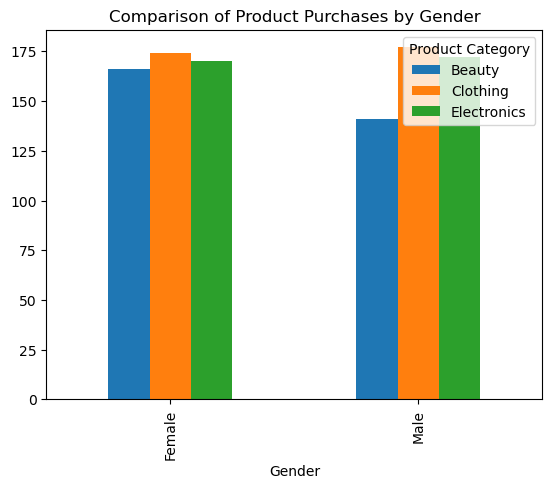

In [13]:
# Comparison of Product Purchases by Gender .
df.groupby("Gender")['Product Category'].value_counts().unstack().plot.bar()
plt.title("Comparison of Product Purchases by Gender")
plt.show()

In [14]:
# female customers purchase Beauty Products that's the highest purchased .
# clothing are also  higher purchased and the Electronics are sightly less purchased .

# male customers purchase clothing has the highest purchase count .
# Electronics is also high but less than clothing .

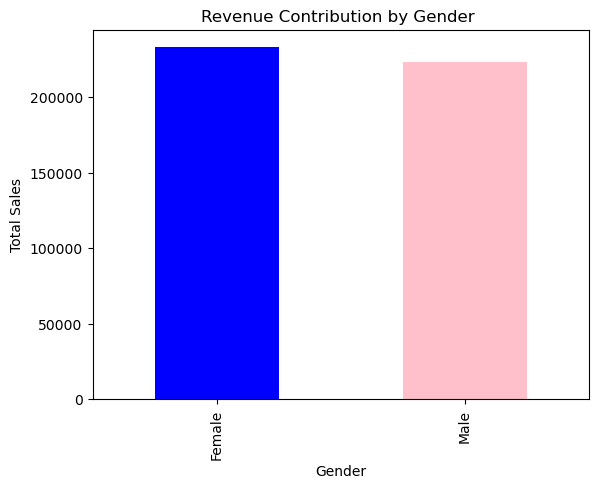

In [15]:
# Revenue Contribution by Gender.
df.groupby("Gender")['Total Amount'].sum().plot(kind = "bar", color = ['blue','pink'])
plt.title("Revenue Contribution by Gender ")
plt.ylabel("Total Sales")
plt.show()


In [16]:
# Average Order Value (AOV) by Gender .
df.groupby('Gender')['Total Amount'].mean().round(2)


Gender
Female    456.55
Male      455.43
Name: Total Amount, dtype: float64

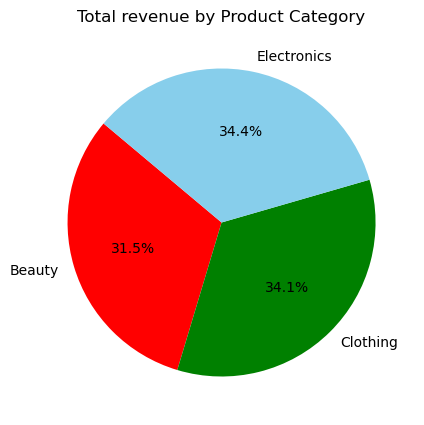

In [17]:
# Revenue by Category
df1 = df.groupby('Product Category')['Total Amount'].sum()
plt.figure(figsize=(8,5))
plt.pie(df1,labels = df1.index,
       autopct = "%1.1f%%",
       startangle = 140,
       colors=["red","green","skyblue"])
plt.title("Total revenue by Product Category")
plt.show()

In [18]:
# Electronics is the most profitable category , contributing the maximum revenue .
# clothing is also profitable but behind Electronics .
# Beauty products have the lowest revenue .

In [19]:
# whether Electronics brings more revenue than Beauty or Clothing .

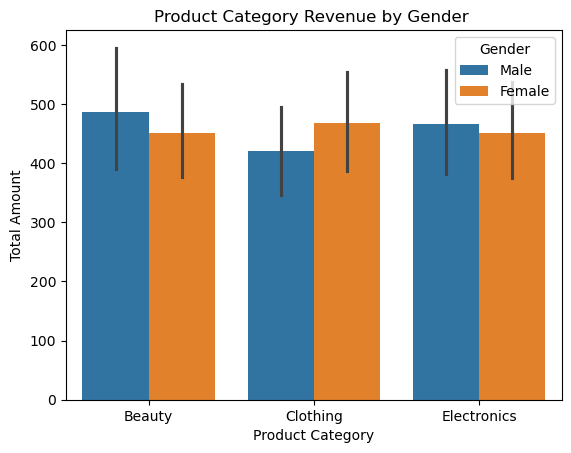

In [20]:
# Product Category preference by Gender 
df.groupby(['Gender','Product Category'])['Total Amount'].sum()
sns.barplot(data = df ,x = 'Product Category', y = 'Total Amount', hue = 'Gender' )
plt.title("Product Category Revenue by Gender ")
plt.show()


In [21]:
# females may spend more on Beauty and Clothing 
# Males may spend more on Electronics, Clothing 

C:\Users\Admin\AppData\Local\Temp\ipykernel_35184\2492181034.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = "Product Category", y = "Quantity", data = df , palette ="pastel")


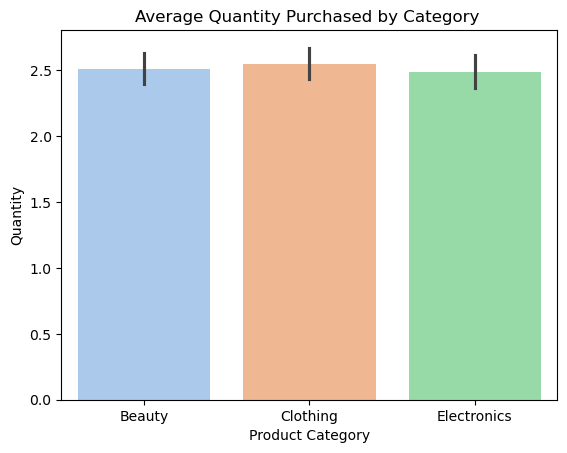

In [22]:
# Average Quantity Purchased by Category
df.groupby("Product Category")['Quantity'].mean()
sns.barplot(x = "Product Category", y = "Quantity", data = df , palette ="pastel")
plt.title("Average Quantity Purchased by Category ")
plt.show()

In [ ]:
# Electronics and Beauty categories have a higher average purchase quantity, compared to clothing ,
# which has the lowest average quantity.
# This indicates that customers tend to buy more units from Electronics and Beauty products,
# while clothing items are bought in smaller quantities.

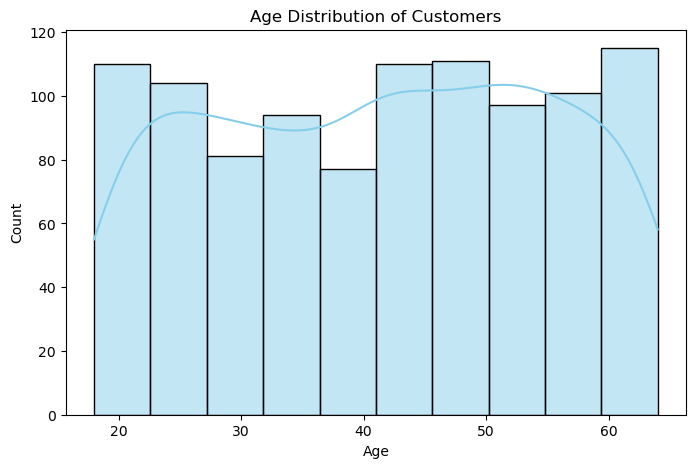

In [15]:
# Age Distribution of Customers .
plt.figure(figsize=(8,5))
sns.histplot(df['Age'],bins=10,kde=True,color="skyblue")
plt.title("Age Distribution of Customers")
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [ ]:
# Most customers are between 20-60 years, with higher counts in 20-30 and 50-60 age groups.
# customers are mainly young and older adults , focus marketing on these age ranges  .

C:\Users\Admin\AppData\Local\Temp\ipykernel_9340\3805348638.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = 'Product Category' ,y = 'Age', palette = "pastel" )


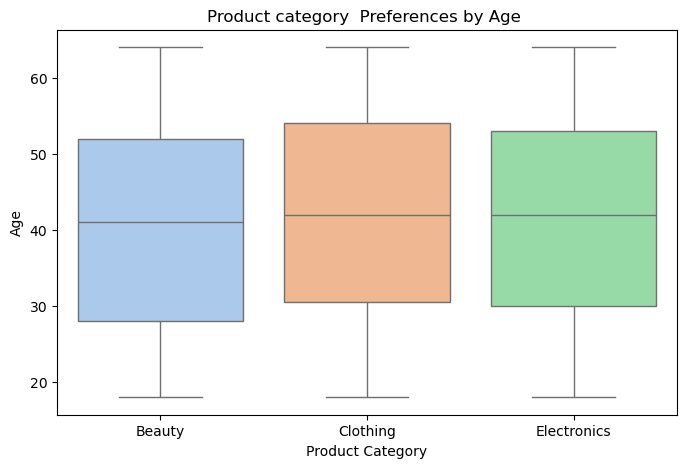

In [13]:
# Product category preferences by age
plt.figure(figsize=(8,5))
sns.boxplot(data = df, x = 'Product Category' ,y = 'Age', palette = "pastel" )
plt.title("Product category  Preferences by Age ")
plt.show()

In [ ]:
# younger age groups(around 24 - 32 years) prefer to Clothing and Electronics more.
# middle-aged groups(around 40-80 years) show balanced purchases across all product categories.
# older age groups(56 and above)tend to buy Beauty and Electronics products slightly more than clothing.

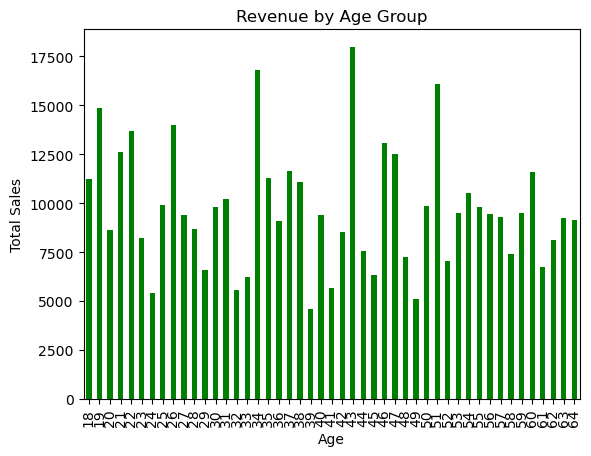

In [24]:
# Revenue by Age group
df.groupby("Age")['Total Amount'].sum().plot(kind = "bar",color = "green")
plt.title("Revenue by Age Group")
plt.ylabel("Total Sales")
plt.show()

In [ ]:
# the age group around 30-40 years shows the highest total sales
# yonger(below 25 years)and older(above 55 years) age groups show comparatively lower sales.
# Most revenue is generated from customers in the 30-45 age range.

In [ ]:
# Key insights  / conclusion :-
# Clothing category generates the highest revenue .
# Beauty products are sightly more popular among female customers .
# Most buyers are good between 25-40 years .
# Average spending by male and female customers is nearly similar .
# Electronics have consistent but lower total revenue compared to other Categories .